RESPONSI SDM
Bayu Kurniawan (21/480093/GE/09662)
Wening Asih Diva Aprilia (21/474301/GE/09528)

Load Library/Package

In [1]:
import os
import numpy as np
import pandas as pd
import ast
import torch
import PIL
from tqdm.auto import tqdm
import shutil as sh
from pathlib import Path
import random

from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from pathlib import Path
import random
from IPython.display import Image, display

Load satu gambar untuk training secara random

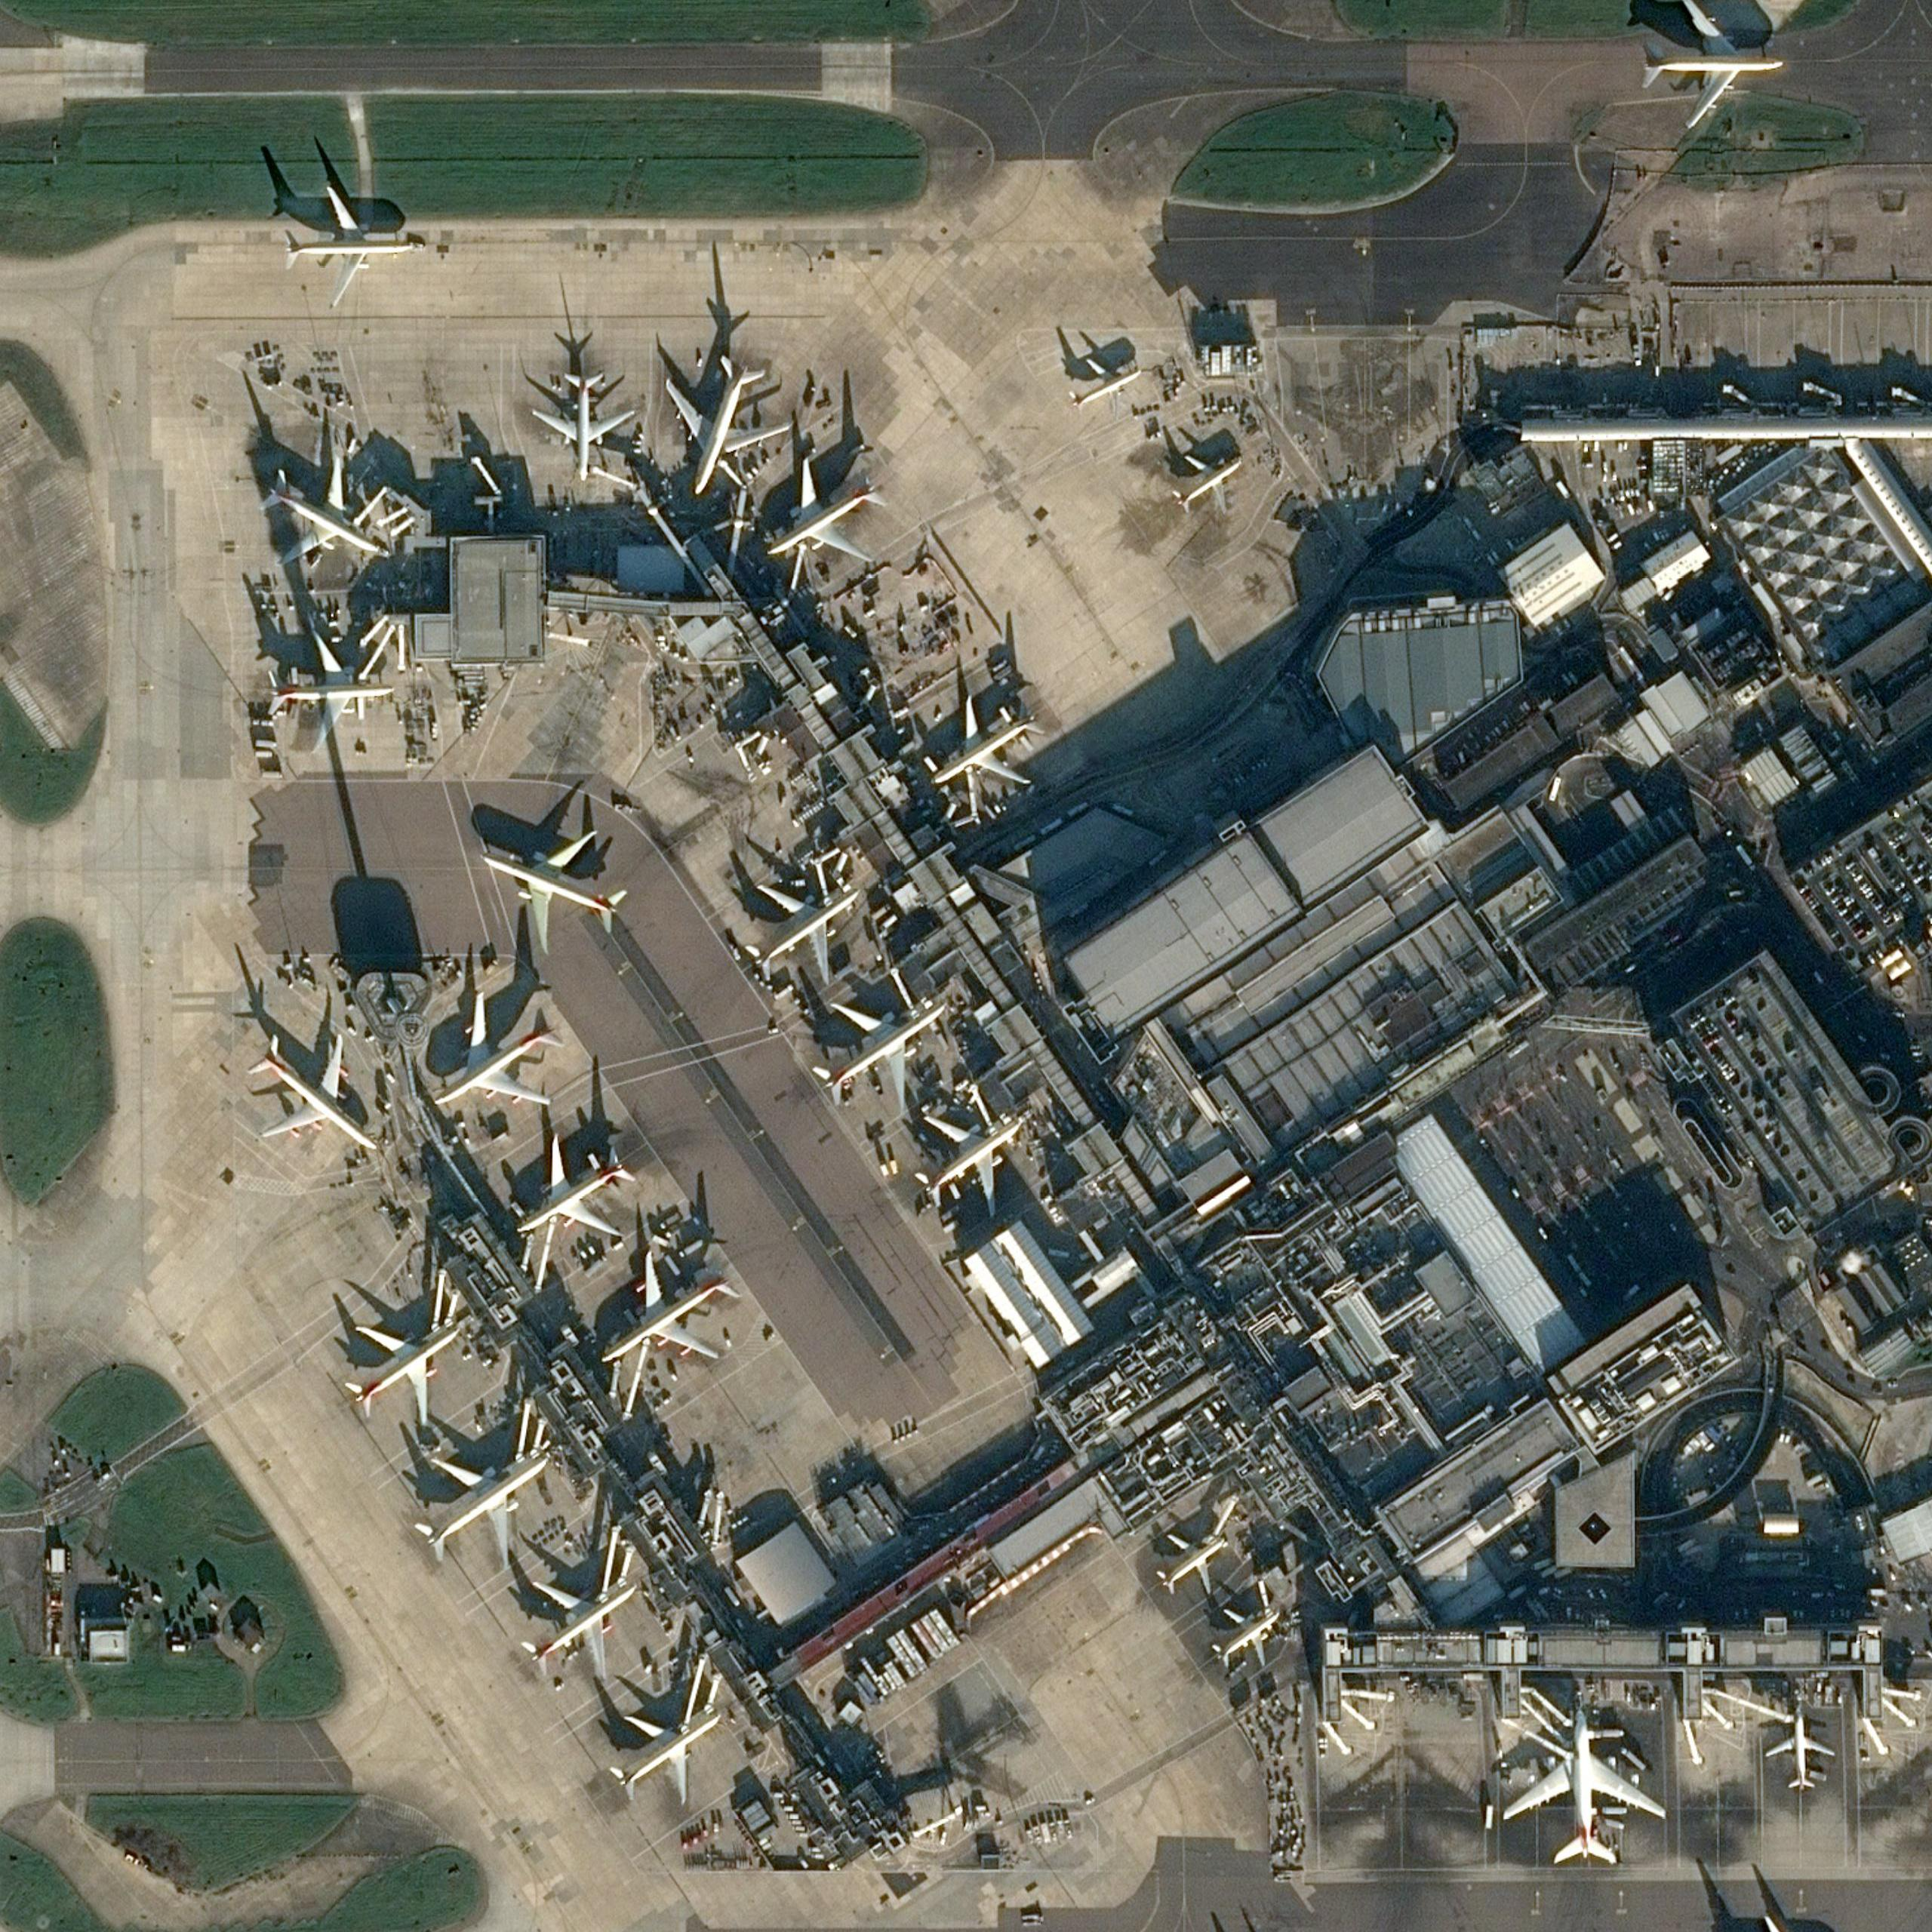

In [3]:
from pathlib import Path
import random
from IPython.display import Image, display

# Direktori data gambar
DATA_DIR = Path('D:/KPJ/Semester 6/SDM/Responsi SDM/Archive')

img_list = list(DATA_DIR.glob('images/*.jpg'))

# Ambil gambar random
pickone = random.choice(img_list)

display(Image(filename=pickone))

Konversi dari data Anotasi berformat CSV

In [61]:
from pathlib import Path
DATA_DIRANOT = "D:/KPJ/Semester 6/SDM/Responsi SDM/Archive/annotations2.csv"
df = pd.read_csv(DATA_DIRANOT)
# convert a string record into a valid python object
def f(x): 
    return ast.literal_eval(x.rstrip('\r\n'))

df = pd.read_csv(DATA_DIRANOT, 
                converters={'geometry': f})
df.head(10)

,id,image_id,geometry,class
0,1,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(135, 522), (245, 522), (245, 600), (135, 600...",Pesawat
1,2,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1025, 284), (1125, 284), (1125, 384), (1025,...",Pesawat
2,3,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1058, 1503), (1130, 1503), (1130, 1568), (10...",Pesawat
3,4,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(813, 1518), (885, 1518), (885, 1604), (813, ...",Pesawat
4,5,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(594, 938), (657, 938), (657, 1012), (594, 10...",Pesawat
5,6,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(451, 725), (524, 725), (524, 798), (451, 798...",Pesawat
6,7,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1543, 1437), (1614, 1437), (1614, 1497), (15...",Pesawat
7,8,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1485, 1370), (1561, 1370), (1561, 1437), (14...",Pesawat
8,9,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1968, 1624), (2053, 1624), (2053, 1687), (19...",Pesawat
9,10,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1659, 1674), (1733, 1674), (1733, 1746), (16...",Pesawat


Konversi anotasi menjadi geometri dan mencari bounds

In [62]:
import pandas as pd
import numpy as np
import ast

# Path ke CSV asli dan CSV hasil output
#input_csv_path = "D:/KPJ/Semester 6/SDM/Responsi SDM/Archive/annotations2.csv"
#output_csv_path = "D:/KPJ/Semester 6/SDM/Responsi SDM/Archive/annotations_with_bounds.csv"

# Membaca CSV asli
#df = pd.read_csv(input_csv_path, converters={'geometry': ast.literal_eval})

def getBounds(geometry):
    try: 
        arr = np.array(geometry).T
        xmin = np.min(arr[0])
        ymin = np.min(arr[1])
        xmax = np.max(arr[0])
        ymax = np.max(arr[1])
        return (xmin, ymin, xmax, ymax)
    except:
        return np.nan

def getWidth(bounds):
    try: 
        (xmin, ymin, xmax, ymax) = bounds
        return np.abs(xmax - xmin)
    except:
        return np.nan

def getHeight(bounds):
    try: 
        (xmin, ymin, xmax, ymax) = bounds
        return np.abs(ymax - ymin)
    except:
        return np.nan

# Membuat kolom baru untuk bounds, width, dan height
df['bounds'] = df['geometry'].apply(getBounds)
df['width'] = df['bounds'].apply(getWidth)
df['height'] = df['bounds'].apply(getHeight)

# Menampilkan 10 baris pertama dari DataFrame
print(df.head(10))


   id                                  image_id  \
0   1  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
1   2  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
2   3  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
3   4  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
4   5  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
5   6  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
6   7  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
7   8  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
8   9  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   
9  10  4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg   

                                            geometry    class  \
0  [(135, 522), (245, 522), (245, 600), (135, 600...  Pesawat   
1  [(1025, 284), (1125, 284), (1125, 384), (1025,...  Pesawat   
2  [(1058, 1503), (1130, 1503), (1130, 1568), (10...  Pesawat   
3  [(813, 1518), (885, 1518), (885, 1604), (813, ...  Pesawat   
4  [(594, 938), (657, 938), (657, 1012), (594, 10...  Pesawat   
5  [(451, 725), (524, 725), (524, 798), (451, 79

Menyimpan hasil anotasi dengan bounds dalam format csv

In [63]:
output_csv_path = "D:/KPJ/Semester 6/SDM/Responsi SDM/Archive/annotations_with_bounds.csv"
# Menyimpan DataFrame ke file CSV baru
df.to_csv(output_csv_path, index=False)

print(f"DataFrame telah disimpan ke {output_csv_path}")


DataFrame telah disimpan ke D:/KPJ/Semester 6/SDM/Responsi SDM/Archive/annotations_with_bounds.csv


Load file anotasi dengan bounds yang telah disimpan sebelumnya

In [6]:
from pathlib import Path
DATA_DIRANOT = "D:/KPJ/Semester 6/SDM/Responsi SDM/Archive/annotations_with_bounds.csv"
df = pd.read_csv(DATA_DIRANOT)
# convert a string record into a valid python object
def f(x): 
    return ast.literal_eval(x.rstrip('\r\n'))

df = pd.read_csv(DATA_DIRANOT, 
                converters={'geometry': f})
df.head(10)

,id,image_id,geometry,class,bounds,width,height
0,1,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(135, 522), (245, 522), (245, 600), (135, 600...",Pesawat,"(135, 522, 245, 600)",110,78
1,2,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1025, 284), (1125, 284), (1125, 384), (1025,...",Pesawat,"(1025, 284, 1125, 384)",100,100
2,3,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1058, 1503), (1130, 1503), (1130, 1568), (10...",Pesawat,"(1058, 1503, 1130, 1568)",72,65
3,4,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(813, 1518), (885, 1518), (885, 1604), (813, ...",Pesawat,"(813, 1518, 885, 1604)",72,86
4,5,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(594, 938), (657, 938), (657, 1012), (594, 10...",Pesawat,"(594, 938, 657, 1012)",63,74
5,6,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(451, 725), (524, 725), (524, 798), (451, 798...",Pesawat,"(451, 725, 524, 798)",73,73
6,7,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1543, 1437), (1614, 1437), (1614, 1497), (15...",Pesawat,"(1543, 1437, 1614, 1497)",71,60
7,8,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1485, 1370), (1561, 1370), (1561, 1437), (14...",Pesawat,"(1485, 1370, 1561, 1437)",76,67
8,9,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1968, 1624), (2053, 1624), (2053, 1687), (19...",Pesawat,"(1968, 1624, 2053, 1687)",85,63
9,10,4f833867-273e-4d73-8bc3-cb2d9ceb54ef.jpg,"[(1659, 1674), (1733, 1674), (1733, 1746), (16...",Pesawat,"(1659, 1674, 1733, 1746)",74,72


Menampilkan list dari data yang akan digunakan untuk validasi berdasarkan image_id

In [7]:
# create a list of images used for validation
fold = 1
num_fold = 5
index = df['image_id'].unique()
val_indexes = index[len(index)*fold//num_fold:len(index)*(fold+1)//num_fold]
print(val_indexes)

['78099b50-f2b6-4319-b462-f33df2966c45.jpg'
 '22291e0b-ebe2-4f3f-b53e-4e709179300a.jpg'
 'cc4f3226-c262-409e-a4b2-a576e776f7f4.jpg'
 '34ae857d-6e71-46b9-b694-d9e40fb093bc.jpg'
 '5c9e817a-dc4b-42ab-952c-3128e2de12e8.jpg'
 'af67041b-f363-47ae-8ddd-f652db3a6bab.jpg'
 '0263270b-e3ee-41dc-aeef-43ff77e66d5b.jpg'
 'd8873734-016a-4b9d-9b9e-8bc47eb13fef.jpg'
 'd0c3d270-f23e-4792-bac0-142a9cc8ccc6.jpg'
 '78400c58-1a7c-4342-a1fb-2117cb7cbc8b.jpg'
 '77f7b57f-5cf2-424d-a952-9847b3c3f35e.jpg'
 'd9399a45-6745-4e59-8903-90640b2ddf9f.jpg'
 '014de911-7810-4f7d-8967-3e5402209f4a.jpg'
 'd3d2b706-9017-41f4-b57e-469038daa634.jpg'
 '4c9d2482-788c-4d68-a3d4-478b2367abce.jpg'
 '576827bc-a94a-4611-8820-f3d56e969151.jpg'
 '4e9164aa-532e-4b76-bce4-060b090da357.jpg'
 '14436c8c-93ec-41af-9fbf-43a5f39f2b98.jpg'
 '7635d63c-6b97-4c9c-a7dc-27773d42ed4c.jpg'
 'ecfe7982-05e5-435f-824b-e24b6846316e.jpg'
 '8df07836-4606-446e-9880-6ed9e0f74543.jpg']


Load geometri anotasi pada salah satu dataset untuk training

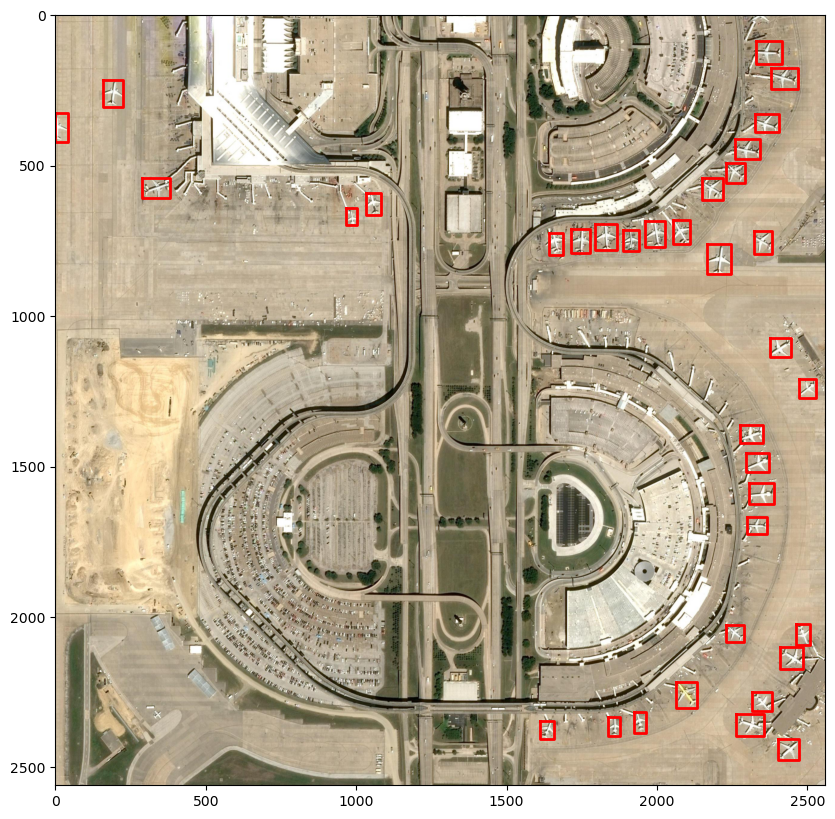

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast
from shapely.geometry import shape, Polygon, LineString
import matplotlib.pyplot as plt
from PIL import Image
import random

# Definisikan direktori data dengan raw string
DATA_DIR = Path(r'D:/KPJ\Semester 6/SDM/Responsi SDM/Archive')

# Baca file CSV
df = pd.read_csv(DATA_DIR / 'annotations2.csv')

# Fungsi untuk mengonversi string geometri menjadi objek geometri shapely
def convert_geometry(geometry_str):
    geometry_list = ast.literal_eval(geometry_str)
    if isinstance(geometry_list[0][0], list):  # Jika geometri adalah daftar list, itu adalah Polygon
        return Polygon(geometry_list[0])
    else:  # Jika geometri adalah list sederhana, itu adalah LineString
        return LineString(geometry_list)

# Terapkan fungsi konversi ke kolom 'geometry'
df['geometry'] = df['geometry'].apply(convert_geometry)

# Pilih kolom yang diinginkan
df = df[['id', 'image_id', 'geometry', 'class']]

# Fungsi untuk mendapatkan bounds dari geometri shapely
def getBounds(geometry):
    try:
        return geometry.bounds
    except:
        return np.nan

# Fungsi untuk mendapatkan lebar dari bounds
def getWidth(bounds):
    try:
        (xmin, ymin, xmax, ymax) = bounds
        return np.abs(xmax - xmin)
    except:
        return np.nan

# Fungsi untuk mendapatkan tinggi dari bounds
def getHeight(bounds):
    try:
        (xmin, ymin, xmax, ymax) = bounds
        return np.abs(ymax - ymin)
    except:
        return np.nan

# Buat kolom bounds, width, dan height
df['bounds'] = df['geometry'].apply(getBounds)
df['width'] = df['bounds'].apply(getWidth)
df['height'] = df['bounds'].apply(getHeight)

# Pilih gambar acak
random_image_id = random.choice(df['image_id'].unique())
image_path = DATA_DIR / f'images/{random_image_id}'  # Pastikan ekstensi .jpg hanya ditambahkan sekali
image = Image.open(image_path)

# Dapatkan anotasi untuk gambar yang dipilih
annotations = df[df['image_id'] == random_image_id]

# Plot gambar dan anotasi
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(image)

for _, row in annotations.iterrows():
    geom = row['geometry']
    if geom.geom_type == 'Polygon':
        x, y = geom.exterior.xy
    elif geom.geom_type == 'LineString':
        x, y = geom.xy
    ax.plot(x, y, color='red', linewidth=2)

plt.show()


Mengambil informasi ukuran gambar untuk split gambar

In [4]:
print(f"Found {len(img_list)} images files in {DATA_DIR}")

img = PIL.Image.open(pickone)
IMAGE_HEIGHT, IMAGE_WIDTH = img.size
num_channels = len(img.mode)
print("Image size: {}".format((IMAGE_HEIGHT, IMAGE_WIDTH)))
print("Num channels: {}".format(num_channels))

Found 103 images files in D:\KPJ\Semester 6\SDM\Responsi SDM\Archive
Image size: (2560, 2560)
Num channels: 3


Spliting data berdasarkan anotasinya

In [12]:
import os 
import tqdm.notebook

# Membuat gambar 512x512 dengan overlap 64 pix overlap
TILE_WIDTH = 512
TILE_HEIGHT = 512
TILE_OVERLAP = 64
TRUNCATED_PERCENT = 0.3
_overwriteFiles = True

TILES_DIR = {'train': Path('pasca/data/train'),
             'val': Path('pasca/data/val')}
for _, folder in TILES_DIR.items():
    if not os.path.isdir(folder):
        os.makedirs(folder)

LABELS_DIR = {'train': Path('pasca/data/train/labels'),
              'val': Path('pasca/data/val/labels')}
for _, folder in LABELS_DIR.items():
    if not os.path.isdir(folder):
        os.makedirs(folder)

# Save one line in .txt file for each tag found inside the tile
def tag_is_inside_tile(bounds, x_start, y_start, width, height, truncated_percent):
    x_min, y_min, x_max, y_max = bounds
    x_min, y_min, x_max, y_max = x_min - x_start, y_min - y_start, x_max - x_start, y_max - y_start

    if (x_min > width) or (x_max < 0.0) or (y_min > height) or (y_max < 0.0):
        return None
    
    x_max_trunc = min(x_max, width) 
    x_min_trunc = max(x_min, 0) 
    if (x_max_trunc - x_min_trunc) / (x_max - x_min) < truncated_percent:
        return None
    y_max_trunc = min(y_max, width) 
    y_min_trunc = max(y_min, 0) 
    if (y_max_trunc - y_min_trunc) / (y_max - y_min) < truncated_percent:
        return None
        
    x_center = (x_min_trunc + x_max_trunc) / 2.0 / width
    y_center = (y_min_trunc + y_max_trunc) / 2.0 / height
    x_extend = (x_max_trunc - x_min_trunc) / width
    y_extend = (y_max_trunc - y_min_trunc) / height
    
    return (0, x_center, y_center, x_extend, y_extend)
            
for img_path in tqdm.notebook.tqdm(img_list):
    # Open image and related data
    pil_img = PIL.Image.open(img_path, mode='r')
    np_img = np.array(pil_img, dtype=np.uint8)

    # Get annotations for image
    img_labels = df[df["image_id"] == img_path.name]
    #print(img_labels)

    # Count number of sections to make
    X_TILES = (IMAGE_WIDTH + TILE_WIDTH + TILE_OVERLAP - 1) // TILE_WIDTH 
    Y_TILES = (IMAGE_HEIGHT + TILE_HEIGHT + TILE_OVERLAP - 1) // TILE_HEIGHT
    
    # Cut each tile
    for x in range(X_TILES):
        for y in range(Y_TILES):

            x_end = min((x + 1) * TILE_WIDTH - TILE_OVERLAP * (x != 0), IMAGE_WIDTH)
            x_start = x_end - TILE_WIDTH
            y_end = min((y + 1) * TILE_HEIGHT - TILE_OVERLAP * (y != 0), IMAGE_HEIGHT)
            y_start = y_end - TILE_HEIGHT
            #print(x_start, y_start)
            
            folder = 'val' if img_path.name in val_indexes else 'train'
            save_tile_path = TILES_DIR[folder].joinpath(img_path.stem + "_" + str(x_start) + "_" + str(y_start) + ".jpg")
            save_label_path = LABELS_DIR[folder].joinpath(img_path.stem + "_" + str(x_start) + "_" + str(y_start) + ".txt")
                
            # Save if file doesn't exit
            if _overwriteFiles or not os.path.isfile(save_tile_path):
                cut_tile = np.zeros(shape=(TILE_WIDTH, TILE_HEIGHT, 3), dtype=np.uint8)
                cut_tile[0:TILE_HEIGHT, 0:TILE_WIDTH, :] = np_img[y_start:y_end, x_start:x_end, :]
                cut_tile_img = PIL.Image.fromarray(cut_tile)
                cut_tile_img.save(save_tile_path)

            found_tags = [
                tag_is_inside_tile(bounds, x_start, y_start, TILE_WIDTH, TILE_HEIGHT, TRUNCATED_PERCENT)
                for i, bounds in enumerate(img_labels['bounds'])]
            found_tags = [el for el in found_tags if el is not None]

            # save labels
            with open(save_label_path, 'w+') as f:
                for tags in found_tags:
                    f.write(' '.join(str(x) for x in tags) + '\n')


  0%|          | 0/103 [00:00<?, ?it/s]

Menentukan konfigurasi untuk jumlah kelas, nama kelas, dan lokasi data train/test. Kemudian menyimpannya dalam format yaml

In [31]:
CONFIG = """
# train and val datasets (image directory or *.txt file with image paths)
train: /pasca/data/train
val: /pasca/data/val

# number of classes
nc: 1

# class names
names: ['Pesawaty']
"""

# Menyimpan konfigurasi ke file data.yaml
with open("pesawat.yaml", "w") as f:
    f.write(CONFIG)


Memilih device untuk melakukan training

In [4]:
print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

Setup complete. Using torch 2.3.0+cu121 _CudaDeviceProperties(name='NVIDIA GeForce GTX 1650', major=7, minor=5, total_memory=4095MB, multi_processor_count=14)


In [5]:
torch.backends.cudnn.enabled = False

TRAINING

Memastikan train dan val ada pada tempatnya

In [6]:
import os

train_path = "pasca/data/train/images"
val_path = "pasca/data/val/images"

if not os.path.exists(train_path):
    print(f"Train path not found: {train_path}")
else:
    print(f"Train path exists: {train_path}")

if not os.path.exists(val_path):
    print(f"Val path not found: {val_path}")
else:
    print(f"Val path exists: {val_path}")

Train path exists: pasca/data/train/images
Val path exists: pasca/data/val/images


Training model pada dataset dengan model dari Yolov8s dengan konfigurasi pada pesawat.yaml dengan epoch 10 dan batch yang dioptimalkan dengan kemampuan device (batch = -1 berarti model mencari batch optimal sesuai dengan kemampuan device)

In [8]:
from ultralytics import YOLO

# Load model
model = YOLO('yolov8s.pt')  # Load a new YOLO model with config file

# Training
model.train(data='pesawat.yaml', epochs=10, imgsz=512, batch=-1)

New https://pypi.org/project/ultralytics/8.2.46 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.28  Python-3.11.7 torch-2.3.0+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=pesawat.yaml, epochs=10, time=None, patience=100, batch=-1, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frame

train: Scanning D:\KPJ\Semester 6\SDM\Responsi SDM\Archive\pasca\data\train\labels.cache... 2952 images, 1419 backgrounds, 0 corrupt: 100%|██████████| 2952/2952 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



val: Scanning D:\KPJ\Semester 6\SDM\Responsi SDM\Archive\pasca\data\val\labels.cache... 756 images, 273 backgrounds, 0 corrupt: 100%|██████████| 756/756 [00:00<?, ?it/s]


Plotting labels to runs\detect\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.000515625), 63 bias(decay=0.0)
Image sizes 512 train, 512 val
Using 8 dataloader workers
Logging results to runs\detect\train
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        756       1459      0.968      0.848        0.9      0.643



10 epochs completed in 1.863 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 22.5MB
Optimizer stripped from runs\detect\train\weights\best.pt, 22.5MB

Validating runs\detect\train\weights\best.pt...
Ultralytics YOLOv8.2.28  Python-3.11.7 torch-2.3.0+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [01:06<00:00,  1.89s/it]


                   all        756       1459      0.954      0.853      0.902      0.651
Speed: 0.2ms preprocess, 83.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001FA06E41990>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

Predict

Melakukan prediksi pada image BuatPredict.tif yang merupakan citra bandara Soekarno Hatta

In [9]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n model
model = YOLO("runs/detect/train/weights/best.pt")

# Run inference on 'bus.jpg' with arguments
model.predict("BuatPredict.tif", save=True, imgsz=1881, conf=0.5)


WARNING  imgsz=[1881] must be multiple of max stride 32, updating to [1888]
image 1/1 d:\KPJ\Semester 6\SDM\Responsi SDM\Archive\BuatPredict.tif: 1440x1888 11 Pesawats, 155.9ms
Speed: 22.0ms preprocess, 155.9ms inference, 2.0ms postprocess per image at shape (1, 3, 1440, 1888)
Results saved to runs\detect\predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Pesawat'}
 obb: None
 orig_img: array([[[ 72,  83,  81],
         [ 69,  80,  78],
         [ 65,  76,  74],
         ...,
         [141, 167, 179],
         [146, 172, 184],
         [148, 174, 186]],
 
        [[ 75,  86,  84],
         [ 73,  84,  82],
         [ 68,  79,  77],
         ...,
         [141, 167, 179],
         [141, 167, 179],
         [142, 168, 180]],
 
        [[ 76,  87,  85],
         [ 74,  85,  83],
         [ 70,  81,  79],
         ...,
         [140, 166, 178],
         [139, 165, 177],
         [139, 165, 177]],
 
        ...,
 
        [[135, 173, 203],
         [132, 169, 197],
         [137, 172, 198],
         ...,
         [  6,  64,  29],
         [ 13,  70,  32],
         [ 17,  74,  36]],
 
        [[136, 174, 204],
         [135, 172, 200],
         [140, 175, 201],
         ...,
         [  5,  6

Melakukan ploting akurasi mAP50

In [16]:
import plotly.express as px
import pandas as pd

df = pd.read_csv("runs/detect/train/results.csv")
fig = px.line(df, x='                  epoch', y='       metrics/mAP50(B)', title='mAP50')
fig.show()

Menghitung akurasi validasi dari mAP50, mAP75, dan mAP50-95 beserta informasi metrik lainnya

In [18]:
from ultralytics import YOLO

# Load your model
model = YOLO("runs/detect/train/weights/best.pt")

# Validate the model
metrics = model.val()
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP75: {metrics.box.map75}")

Ultralytics YOLOv8.2.28  Python-3.11.7 torch-2.3.0+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning D:\KPJ\Semester 6\SDM\Responsi SDM\Archive\pasca\data\val\labels.cache... 756 images, 273 backgrounds, 0 corrupt: 100%|██████████| 756/756 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [00:19<00:00,  2.47it/s]


                   all        756       1459      0.952      0.851      0.901      0.651


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001F985ACF380>
Traceback (most recent call last):
  File "c:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "c:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py", line 1437, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Speed: 0.3ms preprocess, 17.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs\detect\val
mAP50-95: 0.6509663351477067
mAP50: 0.901155610342229
mAP75: 0.8012187516196881


Menampilkan hasil prediksi

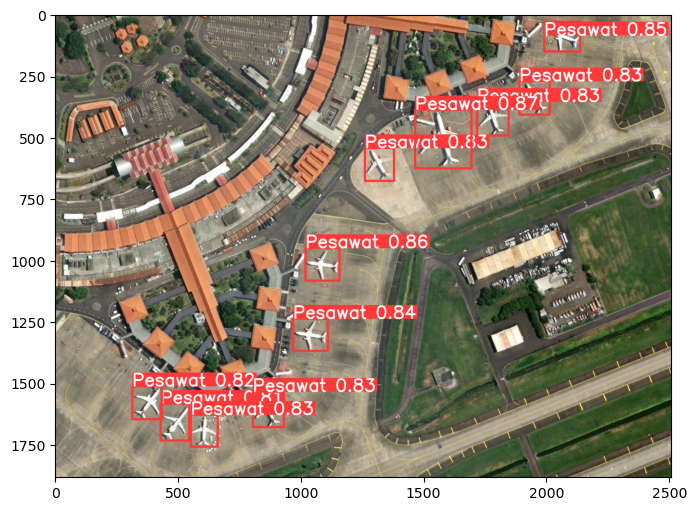

<Axes: >

In [15]:
import rasterio
from rasterio.plot import show


tif_path = 'runs/detect/predict/BuatPredict.tif'
tif = rasterio.open(tif_path)
plt.figure(figsize=(8, 6))
show(tif, cmap='terrain')  



Referensi : 
https://www.kaggle.com/code/jeffaudi/aircraft-detection-with-yolov8 
Dataset :
https://www.kaggle.com/datasets/airbusgeo/airbus-aircrafts-sample-dataset/data